In [2]:
import pandas as pd
import numpy as np
from sklearn.datasets import fetch_openml

# Fetching a clean gene expression benchmark dataset (Golub Leukemia)
print("Loading dataset...")
data = fetch_openml(name='leukemia', version=1, as_frame=True)

# Separate features (gene expression values) and target labels (disease classes)
X = data.data
y = data.target

print("Dataset loaded successfully!")
print(f"Feature matrix shape (Patients, Genes): {X.shape}")
print(f"Target labels shape: {y.shape}")

Loading dataset...
Dataset loaded successfully!
Feature matrix shape (Patients, Genes): (72, 7129)
Target labels shape: (72,)


In [3]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

# 1. Check unique target labels
print("Original target labels:", y.unique())

# 2. Encode text labels into binary integers (0 and 1)
le = LabelEncoder()
y_encoded = le.fit_transform(y)
print("Encoded target labels mapping:", dict(zip(le.classes_, range(len(le.classes_)))))

# 3. Check for any missing values in the feature matrix
missing_count = X.isnull().sum().sum()
print(f"Total missing values in features: {missing_count}")

# 4. Stratified Train-Test Split (80% train, 20% test)
# Stratify ensures the ratio of disease/healthy patients stays balanced in both splits
X_train, X_test, y_train, y_test = train_test_split(
    X, y_encoded, test_size=0.2, random_state=42, stratify=y_encoded
)

print(f"\nTraining features shape: {X_train.shape}")
print(f"Testing features shape: {X_test.shape}")

Original target labels: ['ALL', 'AML']
Categories (2, object): ['ALL', 'AML']
Encoded target labels mapping: {'ALL': 0, 'AML': 1}
Total missing values in features: 0

Training features shape: (57, 7129)
Testing features shape: (15, 7129)


In [4]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, accuracy_score, roc_auc_score

# 1. Initialize and train the Random Forest Classifier
print("Training Random Forest Classifier...")
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)

# 2. Make predictions on the test set
y_pred = rf_model.predict(X_test)
y_prob = rf_model.predict_proba(X_test)[:, 1] # Probability of the positive class (AML)

# 3. Evaluate the results
accuracy = accuracy_score(y_test, y_pred)
roc_auc = roc_auc_score(y_test, y_prob)

print(f"\nModel Accuracy: {accuracy:.4f}")
print(f"ROC-AUC Score: {roc_auc:.4f}\n")

print("Detailed Classification Report:")
print(classification_report(y_test, y_pred, target_names=['ALL', 'AML']))

Training Random Forest Classifier...

Model Accuracy: 0.9333
ROC-AUC Score: 0.9800

Detailed Classification Report:
              precision    recall  f1-score   support

         ALL       0.91      1.00      0.95        10
         AML       1.00      0.80      0.89         5

    accuracy                           0.93        15
   macro avg       0.95      0.90      0.92        15
weighted avg       0.94      0.93      0.93        15



Top 10 Most Predictive Biomarker Genes:
             Gene  Importance
2287    M84526_at    0.027801
759     D88422_at    0.019862
1833    M23197_at    0.017848
6854    M31523_at    0.016354
1778    M19507_at    0.015148
6346  M63838_s_at    0.014429
2127    M63379_at    0.012945
4620    X79067_at    0.012598
6375  M83652_s_at    0.012436
4228    X52056_at    0.012196


/tmp/ipykernel_624/2888237980.py:20: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


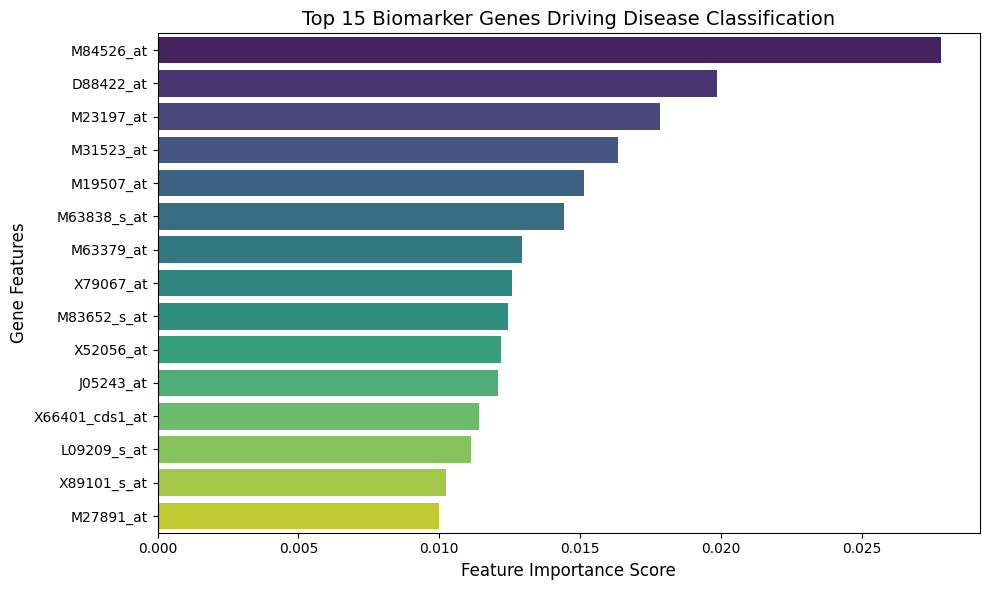

In [5]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Extract feature importances from the trained Random Forest model
importances = rf_model.feature_importances_
feature_names = X.columns

# 2. Create a dataframe of features and their importance scores
feature_importance_df = pd.DataFrame({
    'Gene': feature_names,
    'Importance': importances
}).sort_values(by='Importance', ascending=False)

# 3. Print the top 10 most important biomarker genes
print("Top 10 Most Predictive Biomarker Genes:")
print(feature_importance_df.head(10))

# 4. Plot the top 15 genes
plt.figure(figsize=(10, 6))
sns.barplot(
    x='Importance',
    y='Gene',
    data=feature_importance_df.head(15),
    palette='viridis'
)
plt.title('Top 15 Biomarker Genes Driving Disease Classification', fontsize=14)
plt.xlabel('Feature Importance Score', fontsize=12)
plt.ylabel('Gene Features', fontsize=12)
plt.tight_layout()
plt.show()